In [1]:
#%config InlineBackend.figure_formats=['svg']
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

device = 'cuda'

def listdir_nohidden(path):
    for f in os.listdir(path):
        if not f.startswith('.'):
            yield f

from src.Dataset import dataset_TES, dataset_SNSPD
from ParametricTSNE import train_ptsne

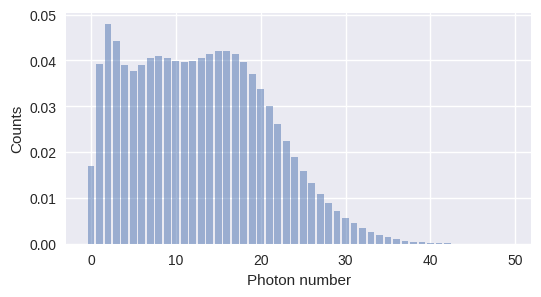

In [2]:
weights = [1.00000000e+00, 8.67567149e-01, 5.11893733e-01, 4.64791825e-01, 
           1.95257413e-01, 3.48166360e-01,1.24623185e-13, 3.89968505e-14, 3.60043421e-01]

weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]#[1]*10

path_save = 'src/Results/Low Dimension'

data_train, data_test, expected_prob = dataset_TES(weights = weights,
                                                signal_size = 8192,
                                                interval = [0,350],#270],
                                                order_dB = False,
                                                plot_expected = True,
                                                n_photon_number = 50)

In [3]:
def plot_loss(model_losses_path: str) -> None:
    """
    Plot learning curve for a model given the path 
    to model's saved loss values.
    """
    loss = np.load(model_losses_path)
    print(loss.shape)
    plt.figure(figsize=(13, 5))
    plt.plot(loss[:,0], label = 'MSE')
    plt.plot(loss[:,1], label = 'KL')
    plt.plot(loss[:,2], label = 'Total')
    plt.legend()
    plt.title(f"Learning curve")
    plt.xlabel("Epochs")
    plt.ylabel("Average loss per batch")
    plt.grid()
    plt.yscale('log')
    plt.show()

In [24]:
def get_embeddings(pretrained_model: torch.nn.Module,
                         input_points: torch.Tensor):
    """
    Yields final embeddings for every batch in dataset
    """
    pretrained_model.eval()
    with torch.no_grad():
        embeddings, reconstruction = pretrained_model(input_points, both = True)
        return embeddings, reconstruction


def plot_embs(pretrained_model: torch.nn.Module,
              input_points_train: torch.Tensor,
              input_points_test: torch.Tensor):
    """
    Plots projection of training points and test points
    """
    X_l1, X_r1 = get_embeddings(pretrained_model, input_points_train)
    X_l2, X_r2 = get_embeddings(pretrained_model, input_points_test)

    X_l1, X_r1 = X_l1.view(-1, 2).cpu().numpy(), X_r1.cpu().numpy()
    X_l2, X_r2 = X_l2.view(-1, 2).cpu().numpy(), X_r2.cpu().numpy()

    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    #ax.hist(X_l1, bins=5000)
    ax.scatter(X_l1[:,0], X_l1[:,1], s=1, alpha=0.05, label='Train')
    ax.scatter(X_l2[:,0], X_l2[:,1], s=1, alpha=0.05, label='Test')
    #ax.hist(X_l1, bins=5000, label='Train')
    #ax.hist(X_l2, bins=5000, label='Test')
    ax.legend()
    #plt.title("MNIST digits parametric t-SNE projection")
    plt.show()


    #plt.figure(figsize=(8, 4))
    #ax = plt.gca()
    #ax.plot(X_r1.T[:,::10], alpha=0.05)
    #ax.plot(X_r2.T[:,::10], alpha=0.05)
    #plt.title("MNIST digits parametric t-SNE projection")
    #plt.show()

    #plt.figure(figsize=(8, 4))
    #ax = plt.gca()
    #ax.plot(input_points_train.cpu().numpy().T[:,::10], alpha=0.05)
    #ax.plot(input_points_test.cpu().numpy().T[:,::10], alpha=0.05)
    #plt.title("MNIST digits parametric t-SNE projection")
    #plt.show()

In [5]:
def size_conv(L_in,
              padding : int = 0,
              dilation : int = 1,
              kernel_size : int = 5,
              stride : int = 2):

    return (((L_in + 2*padding - dilation*(kernel_size - 1)) - 1) / stride) + 1

def size_deconv(L_in,
                padding : int = 0,
                dilation : int = 1,
                kernel_size : int = 5,
                stride : int = 2,
                output_padding : int = 0):
    
    return (L_in - 1)*stride - 2*padding + dilation*(kernel_size - 1) + output_padding + 1

In [6]:
size_conv1 = size_conv(350, 
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)
size_conv2 = size_conv(size_conv1,
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)
size_conv3 = size_conv(size_conv2,
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)

size_deconv1 = size_deconv(size_conv3,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)
size_deconv2 = size_deconv(size_deconv1,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)
size_deconv3 = size_deconv(size_deconv2,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)


print(size_conv1, size_conv2, size_conv3)
print(size_deconv1, size_deconv2, size_deconv3)

174.0 86.0 42.0
86.0 174.0 350.0


### Train parametric t-SNE model on train dataset 

In [7]:
data_train.shape

(30550, 350)

In [8]:
103424 / np.array([32, 64, 101, 202, 512])
30550 / np.array([650, 611 , 470, 325, 235, 10 , 5, 2])

array([   47.,    50.,    65.,    94.,   130.,  3055.,  6110., 15275.])

In [27]:
batch_size = [650, 470, 325]
learning_rate = [0.01, 0.02, 0.003, 0.0003, 0.00004]
early_exaggeration_constant = [2, 6, 10, 20, 30]
perplexity = [200, 300, 400, 500, 600]#np.sqrt(30550)
size_layer = [100, 300, 500, 700, 900]

for n in range(1,5+1):
    for e in tqdm(learning_rate):
        for l in size_layer:
    
            train_ptsne(X_high = data_train[:30000],
                        dim_emb = 2,
                        perplexity = 400,
                        model_name = f'{n} {e} {l}',
                        layer_size = l,
                        n_layer = n,
                        n_epochs = 15,
                        dev = device,
                        save_dir_path= 'runs/run transformer/',
                        early_exaggeration = 10,
                        early_exaggeration_constant = 12,
                        learning_rate = e,
                        alpha_loss = 0.,
                        batch_size = 3000,#3055,
                        dist_func_name = 'euc',
                        bin_search_tol = 1e-4,
                        bin_search_max_iter = 200,
                        min_allowed_sig_sq = 0,
                        max_allowed_sig_sq = 1000,
                        verbose = False)

  0%|                                                                                             | 0/5 [00:00<?, ?it/s]

Model saved as runs/run transformer/ -> 1 0.01 100
Model saved as runs/run transformer/ -> 1 0.01 300
Model saved as runs/run transformer/ -> 1 0.01 500


  0%|                                                                                             | 0/5 [01:44<?, ?it/s]


KeyboardInterrupt: 

In [28]:
ref_path = 'runs/run transformer/'
config_files = listdir_nohidden(f'{ref_path}config')
loss_files = listdir_nohidden(f'{ref_path}loss')
print(config_files)

pos = []
MSE = []
KL = []
tot = []

best_MSE_file = ''
best_KL_file = ''
best_tot_file = ''

best_MSE = 10
best_KL = 10
best_tot = 10

for cf, lf in zip(config_files, loss_files):

        
    loss = np.load(f'{ref_path}loss/{lf}')
    with open(f'{ref_path}config/{cf}') as f:
        config = dict(json.load(f))

    pos.append([config['batch_size'], config['early_exaggeration_constant']])
    
    loss_MSE, loss_KL, loss_tot = loss[-1]

    MSE.append(loss_MSE)
    KL.append(loss_KL)
    tot.append(loss_tot)

    if loss_MSE < best_MSE:
        best_MSE_file = lf
        best_MSE = loss_MSE

    if loss_KL < best_KL:
        best_KL_file = lf
        best_KL = loss_KL

    if loss_tot < best_tot:
        best_tot_file = lf
        best_tot = loss_tot

print(f'Best MSE : {best_MSE} ({best_MSE_file})')
print(f'Best KL : {best_KL} ({best_KL_file})')
print(f'Best tot : {best_tot} ({best_tot_file})')

"""
plt.figure()
plt.imshow(MSE)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()

plt.figure()
plt.imshow(KL)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()

plt.figure()
plt.imshow(tot)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()
"""

<generator object listdir_nohidden at 0x7f3c56e35d20>
Best MSE : 8.230103558162228e-06 (1 0.01 100.npy)
Best KL : 0.13257355213165284 (1 0.01 100.npy)
Best tot : 8.230103558162228e-06 (1 0.01 100.npy)


"\nplt.figure()\nplt.imshow(MSE)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n\nplt.figure()\nplt.imshow(KL)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n\nplt.figure()\nplt.imshow(tot)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n"

In [29]:
name = '1 0.01 100'
run = 'run transformer'

# Weights of a torch model
model_weights = os.path.join(f'runs/{run}/models', name) + ".pt"

# Json with model's config
model_settings = os.path.join(f'runs/{run}/config', name) + ".json"

# Model's learning curve
model_losses = os.path.join(f'runs/{run}/loss', name) + ".npy"

loaded_model = torch.load(model_weights).to(device=device)

(15, 3)


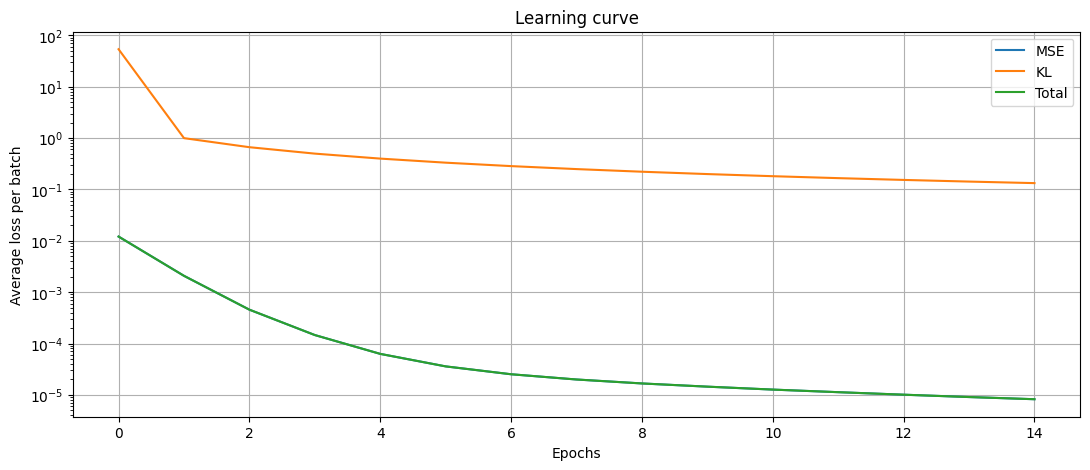

In [30]:
plot_loss(model_losses)

In [25]:
data_train_ = torch.from_numpy(data_train).float().view(-1, 350).to(device=device) 
data_test_ = torch.from_numpy(data_test).float().view(-1, 350).to(device=device)

data_train_ = (data_train_ - data_train_.min()) / (data_train_.max() - data_train_.min())
data_test_ = (data_test_ - data_test_.min()) / (data_test_.max() - data_test_.min())

In [26]:
with plt.style.context("seaborn-v0_8"):
    plot_embs(loaded_model, data_train_, data_test_)

OutOfMemoryError: CUDA out of memory. Tried to allocate 173.84 GiB. GPU 0 has a total capacty of 23.65 GiB of which 19.31 GiB is free. Including non-PyTorch memory, this process has 4.19 GiB memory in use. Of the allocated memory 790.56 MiB is allocated by PyTorch, and 2.96 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [32]:

with plt.style.context("dark_background"):#seaborn-v0_8 dark_background  Solarize_Light2
    dim1, dim2 = (10,10)
    files_ = iter(listdir_nohidden(f'runs/{run}/models'))
    figure, axis = plt.subplots(dim1,dim2, figsize=(50,50)) 

    #g = sns.FacetGrid()

    for i in range(dim1):
        for j in range(dim2):

            model = next(files_)

            loaded_model = torch.load(f'runs/{run}/models/{model}').to(device=device)

            loaded_model.eval()
            with torch.no_grad():
                embeddings = loaded_model(data_train_, encode = True)
                embeddings = embeddings.view(-1, 2).cpu().numpy()

            axis[i,j].set_title(model)
            #axis[i,j].scatter(embeddings[:,0], embeddings[:,1], s=0.1, alpha=0.05, c='khaki')
            axis[i,j].hist(embeddings,bins=5000)
            axis[i,j].set_yticks([])
            axis[i,j].set_xticks([])
    figure.tight_layout()
    plt.savefig('fig.jpg', dpi=200)
    plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 173.84 GiB. GPU 0 has a total capacty of 23.65 GiB of which 21.07 GiB is free. Including non-PyTorch memory, this process has 2.43 GiB memory in use. Of the allocated memory 531.30 MiB is allocated by PyTorch, and 1.45 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [19]:
for file_ in listdir_nohidden(f'runs/{run}/models'):

    loaded_model = torch.load(f'runs/{run}/models/{file_}').to(device)

    with plt.style.context("seaborn-v0_8"):
        plot_embs(loaded_model, data_train_, data_test_)

OutOfMemoryError: CUDA out of memory. Tried to allocate 173.84 GiB. GPU 0 has a total capacty of 23.65 GiB of which 5.74 GiB is free. Including non-PyTorch memory, this process has 17.76 GiB memory in use. Of the allocated memory 15.96 GiB is allocated by PyTorch, and 1.35 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF